In [2]:
netlist = """\
RC Circuit Frequency Response
Vin  in  0  AC  1
R1   in  out  $R
C1   out  0   $C
.SAVE v(in) v(out)
.AC DEC $NPD $FSTART $FSTOP
.END
"""

with open('rc_ac_orig.in', 'w') as f:
    f.write(netlist)

print('rc_ac_orig.in written')

rc_ac_orig.in written


In [3]:
import numpy as np
import ngspice_calc as calc
import matplotlib.pyplot as plt

# Circuit parameters 
R = 1e3          # 1 kΩ
C = 1e-6         # 1 uF

# theoretical cutoff frequency
f_c = 1 / (2 * np.pi * R * C)

# Frequency sweep parameters 
f_start = 1       
f_stop  = 1e6     
npd     = 100     

print(f'R      = {R:.0f} Ω')
print(f'C      = {C*1e6:.1f} uF')
print(f'f_c    = {f_c:.4f} Hz  (theoretical -3dB point)')
print(f'Sweep  = {f_start} Hz to {f_stop:.0e} Hz')
print(f'Points per decade = {npd}')

R      = 1000 Ω
C      = 1.0 uF
f_c    = 159.1549 Hz  (theoretical -3dB point)
Sweep  = 1 Hz to 1e+06 Hz
Points per decade = 100


In [4]:
l = [
    ('$R',      f'{R}'),
    ('$C',      f'{C:.2e}'),
    ('$NPD',    f'{npd}'),
    ('$FSTART', f'{f_start}'),
    ('$FSTOP',  f'{f_stop:.2e}'),
]

calc.replace_strings_1('rc_ac_orig.in', 'rc_ac.in', l)
calc.run_ngspice('rc_ac.in')


No compatibility mode selected!


Circuit: rc circuit frequency response

binary raw file "rc_ac.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 3  

No. of Data Rows : 601

Total analysis time (seconds) = 0.005

Total elapsed time (seconds) = 0.025 

Total DRAM available = 14741.156 MB.
DRAM currently available = 3334.383 MB.
Maximum ngspice program size =   19.906 MB.
Current ngspice program size =   12.094 MB.

Shared ngspice pages =   10.238 MB.
Text (code) pages =    5.316 MB.
Stack = 0 bytes.
Library pages =    1.961 MB.




'rc_ac.raw'

In [5]:
s = calc.slv('rc_ac.in')

for i in range(s.num_plots()):
    print(f"  plot {i}: {s.plotname(i)} | type: {s.analysis_type(i)} | vars: {s.variables(i)}")

  plot 0: AC Analysis | type: tran | vars: ['frequency', 'v(in)', 'v(out)']


In [6]:
freq   = s.get_array('frequency')
v_in   = s.get_array('v(in)')
v_out  = s.get_array('v(out)')

# Transfer function H(f) = Vout / Vin
H = v_out / v_in

gain_db = calc.to_db(H)
phase   = calc.to_degree(H)

print(f'Frequency points : {len(freq)}')
print(f'Freq range       : {freq[0]:.2f} Hz  to  {freq[-1]:.2e} Hz')
print(f'Gain at f_c      : {calc.interp_at(freq, gain_db, f_c):.4f} dB  (expected -3.01 dB)')
print(f'Phase at f_c     : {calc.interp_at(freq, phase,   f_c):.4f} deg (expected -45 deg)')

Frequency points : 601
Freq range       : 1.00 Hz  to  1.00e+06 Hz
Gain at f_c      : -3.0103 dB  (expected -3.01 dB)
Phase at f_c     : -44.9989 deg (expected -45 deg)


In [7]:
# Theoretical H(jw) = 1 / (1 + jwRC)
w = 2 * np.pi * freq
H_theory     = 1 / (1 + 1j * w * R * C)
gain_theory  = calc.to_db(H_theory)
phase_theory = calc.to_degree(H_theory)

print(' At cutoff frequency ')
print(f'{"":20s}  {"NGSPICE":>10}  {"Theory":>10}')
print(f'{"Gain (dB)":20s}  {calc.interp_at(freq, gain_db, f_c):10.4f}  {calc.interp_at(freq, gain_theory, f_c):10.4f}')
print(f'{"Phase (deg)":20s}  {calc.interp_at(freq, phase, f_c):10.4f}  {calc.interp_at(freq, phase_theory, f_c):10.4f}')

 At cutoff frequency 
                         NGSPICE      Theory
Gain (dB)                -3.0103     -3.0103
Phase (deg)             -44.9989    -44.9989


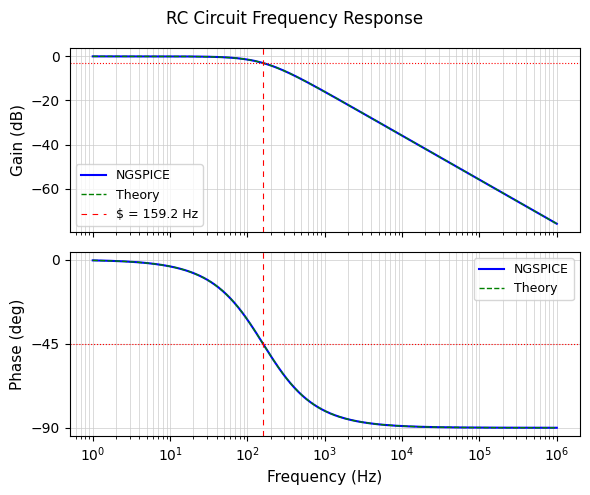

In [8]:
color1 = 'blue'
color2 = 'green'
color3 = 'red'

fig, ax = plt.subplots(2, sharex=True, figsize=(6, 5))
plt.subplots_adjust(hspace=0.08)

# ── Gain plot ────────────────────────────────────────────────
ax[0].semilogx(freq, gain_db,    color=color1, linewidth=1.5, label='NGSPICE')
ax[0].semilogx(freq, gain_theory, color=color2, linewidth=1.0, linestyle='--', label='Theory')
ax[0].axvline(x=f_c, color=color3, linestyle='--', linewidth=0.8, dashes=(5,5), label=f'$ = {f_c:.1f} Hz')
ax[0].axhline(y=-3,  color=color3, linestyle=':',  linewidth=0.8)
ax[0].set_ylabel('Gain (dB)', fontsize=11)
ax[0].legend(fontsize=9)
ax[0].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5, which='both')
ax[0].tick_params(labelbottom=False)

# ── Phase plot ───────────────────────────────────────────────
ax[1].semilogx(freq, phase,        color=color1, linewidth=1.5, label='NGSPICE')
ax[1].semilogx(freq, phase_theory, color=color2, linewidth=1.0, linestyle='--', label='Theory')
ax[1].axvline(x=f_c, color=color3, linestyle='--', linewidth=0.8, dashes=(5,5))
ax[1].axhline(y=-45, color=color3, linestyle=':',  linewidth=0.8)
ax[1].set_ylabel('Phase (deg)', fontsize=11)
ax[1].set_xlabel('Frequency (Hz)', fontsize=11)
ax[1].set_yticks([0, -45, -90])
ax[1].legend(fontsize=9)
ax[1].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5, which='both')

fig.suptitle('RC Circuit Frequency Response', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# ── High-pass: swap C and R in netlist ───────────────────────
netlist_hp ="""\
RC High-Pass Filter
Vin  in  0  AC  1
C1   in  out  {C:.2e}
R1   out  0   {R}
.SAVE v(in) v(out)
.AC DEC {npd} {fstart} {fstop:.2e}
.END
""".format(C=C, R=R, npd=npd, fstart=f_start, fstop=f_stop)


In [16]:

with open('rc_hp.in', 'w') as f:
    f.write(netlist_hp)

calc.run_ngspice('rc_hp.in')



No compatibility mode selected!


Circuit: rc high-pass filter

binary raw file "rc_hp.raw"
Doing analysis at TEMP = 27.000000 and TNOM = 27.000000

No. of Data Columns : 3  

No. of Data Rows : 601

Total analysis time (seconds) = 0.005

Total elapsed time (seconds) = 0.007 

Total DRAM available = 14741.156 MB.
DRAM currently available = 2902.203 MB.
Maximum ngspice program size =   19.906 MB.
Current ngspice program size =   12.176 MB.

Shared ngspice pages =   10.320 MB.
Text (code) pages =    5.316 MB.
Stack = 0 bytes.
Library pages =    1.961 MB.




'rc_hp.raw'

In [17]:
s_hp    = calc.slv('rc_hp.in')
freq_hp = s_hp.get_array('frequency')
v_out_hp = s_hp.get_array('v(out)')
H_hp    = v_out_hp / s_hp.get_array('v(in)')

gain_hp = calc.to_db(H_hp)
phase_hp = calc.to_degree(H_hp)

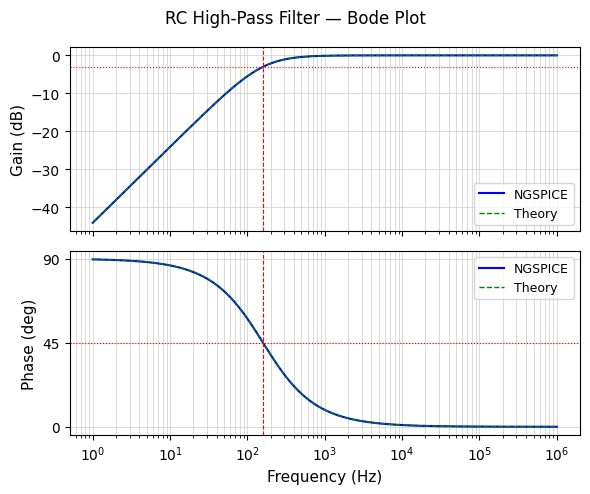

In [18]:
fig, ax = plt.subplots(2, sharex=True, figsize=(6, 5))
plt.subplots_adjust(hspace=0.08)

ax[0].semilogx(freq_hp, gain_hp,         color='blue',  linewidth=1.5, label='NGSPICE')
ax[0].semilogx(freq_hp, gain_theory_hp,  color='green', linewidth=1.0, linestyle='--', label='Theory')
ax[0].axvline(x=f_c, color='red', linestyle='--', linewidth=0.8)
ax[0].axhline(y=-3,  color='red', linestyle=':',  linewidth=0.8)
ax[0].set_ylabel('Gain (dB)', fontsize=11)
ax[0].legend(fontsize=9)
ax[0].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5, which='both')

ax[1].semilogx(freq_hp, phase_hp,         color='blue',  linewidth=1.5, label='NGSPICE')
ax[1].semilogx(freq_hp, phase_theory_hp,  color='green', linewidth=1.0, linestyle='--', label='Theory')
ax[1].axvline(x=f_c, color='red', linestyle='--', linewidth=0.8)
ax[1].axhline(y=45,  color='red', linestyle=':',  linewidth=0.8)
ax[1].set_ylabel('Phase (deg)', fontsize=11)
ax[1].set_xlabel('Frequency (Hz)', fontsize=11)
ax[1].set_yticks([0, 45, 90])
ax[1].legend(fontsize=9)
ax[1].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5, which='both')

fig.suptitle('RC High-Pass Filter — Bode Plot', fontsize=12)
plt.tight_layout()
plt.show()